 # **Analyzing the Impact of Discounts on Profit Margins in a Retail Company**

## **1. Date Cleaning:**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.drop(['Row ID', 'Order ID', 'Customer ID', 'Product ID', 'Postal Code'], axis=1, inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Total days for shipping'] = (df['Ship Date']-df['Order Date']).dt.days
df.head()

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total days for shipping
0,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


####  We fixed the date and time for Ship Date and Order Date.
#### Calculated the total shipment days and called it Total days for shipping.

## **2. Checking for null and duplicate values:**

In [9]:
df.isnull().sum()
# drop any nulls rows
df.dropna(inplace=True)
# checking for duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

#### No duplicates or nulls found.

## **3. Exploratory Data Analysis:**

### Analyzing Ship Mode and Profit:

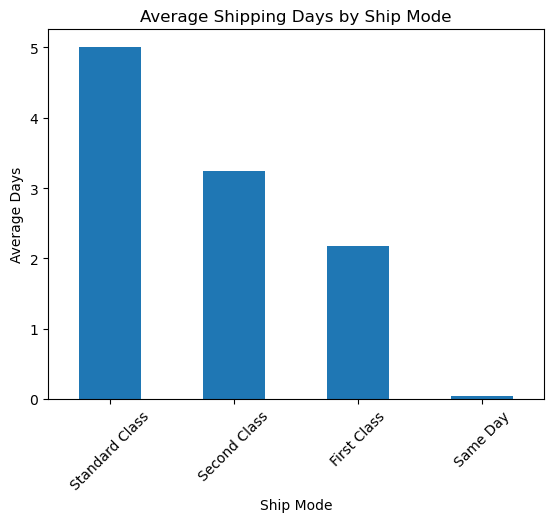

In [16]:
df.groupby('Ship Mode')['Total days for shipping'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Shipping Days by Ship Mode')
plt.ylabel('Average Days')
plt.xlabel('Ship Mode')
plt.xticks(rotation=45)
plt.show()

#### Bar chart to see if ship modes and number of shipping days align --they do.

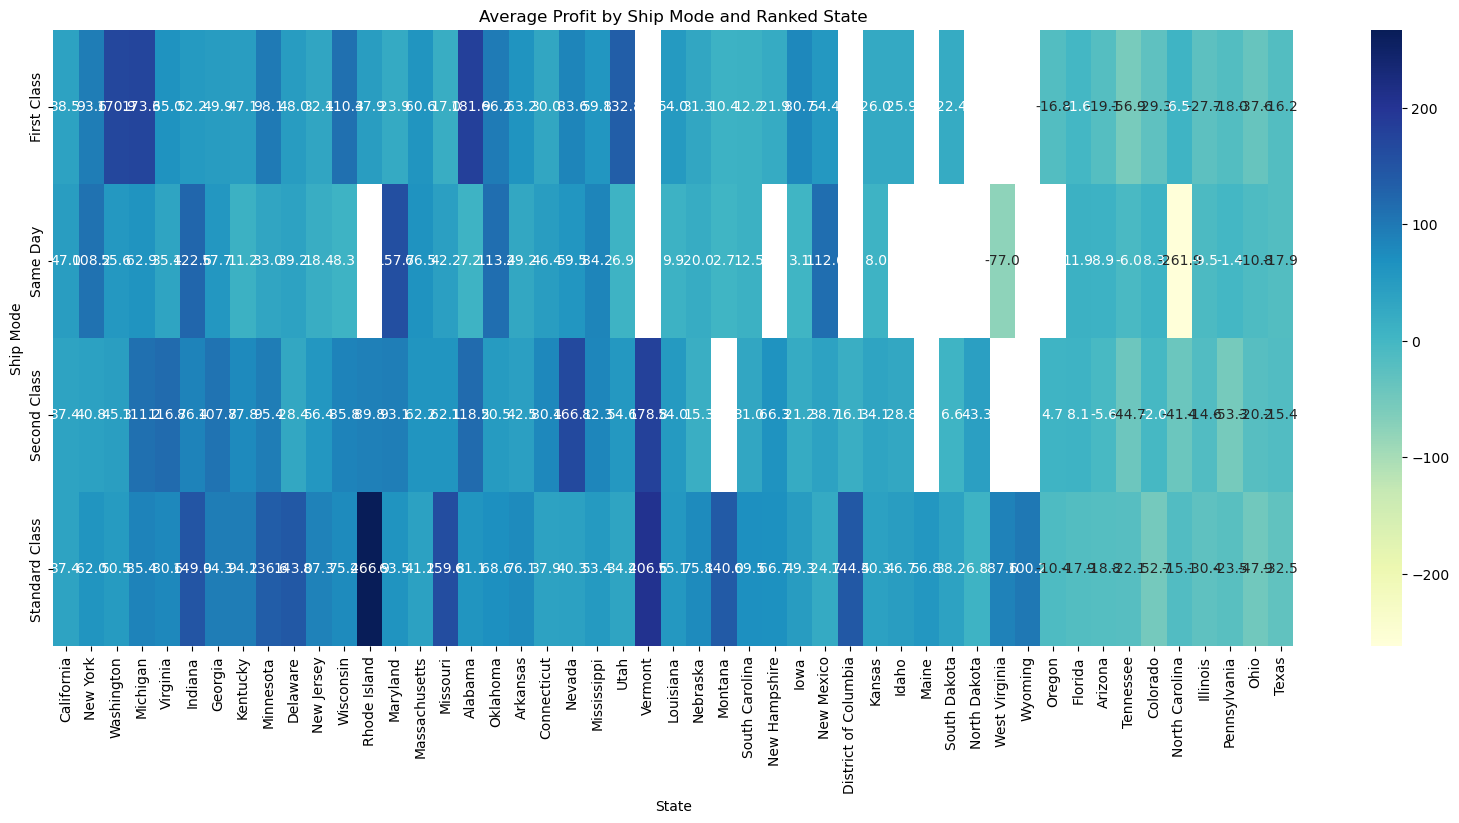

In [19]:
#group the states by profit
state_profit = df.groupby('State')['Profit'].sum().reset_index()
state_profit['Rank'] = state_profit['Profit'].rank(ascending=False, method='dense')
state_profit_sorted = state_profit.sort_values(by='Rank')

# Get the states in ranked order
ordered_states = state_profit_sorted['State'].tolist()

# Create the pivot table of average profit by Ship Mode and State
pivot = df.pivot_table(values='Profit', index='Ship Mode', columns='State', aggfunc='mean')

# Reorder the columns (States) based on profit rank
pivot = pivot[ordered_states]

# Plot the heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title("Average Profit by Ship Mode and Ranked State")
plt.show()

#### There doesn't seem to be any apparent trend with shipment mode and profit.

### Analyzing Profit by Category and Segment :

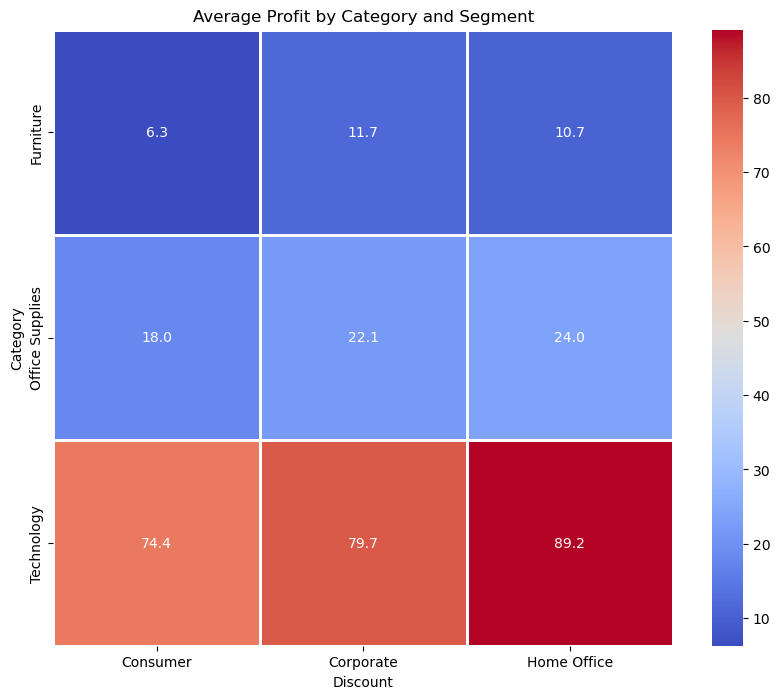

In [23]:
#Plotting a heatmap to compare average profit by category and segment
pivot_table = df.pivot_table(
    index='Category',
    columns='Segment',
    values='Profit',
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='coolwarm', linewidths=1)
plt.title('Average Profit by Category and Segment')
plt.ylabel('Category')
plt.xlabel('Discount')
plt.show()

* We can observe that Home Office and Technology togther have the highest profit.
* These insights can be used to later further explore.
* Home office in general has the highest profits and Consumer has the least Profits.

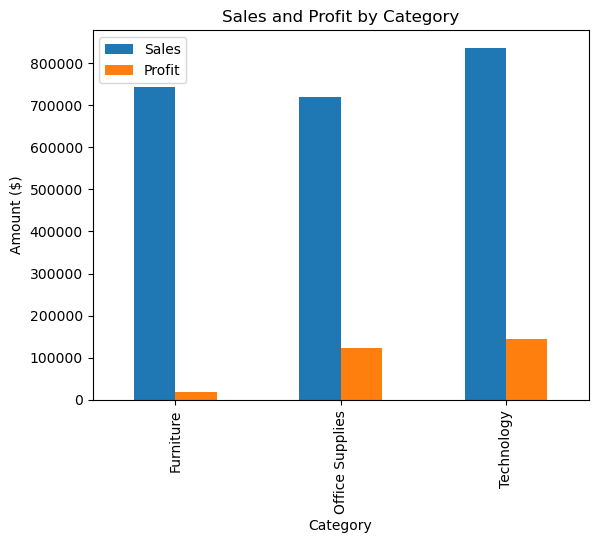

In [26]:
df.groupby('Category')[['Sales', 'Profit']].sum().plot(kind='bar')
plt.title('Sales and Profit by Category')
plt.ylabel('Amount ($)')
plt.show()

* Technology has the highest sales.
* Furniture has the lowest profit.
* These will be further explored later.

### Analyzing Sales by Month and Year:

In [30]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df.head()

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total days for shipping,Year,Month
0,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11
1,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11
2,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6
3,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10
4,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10


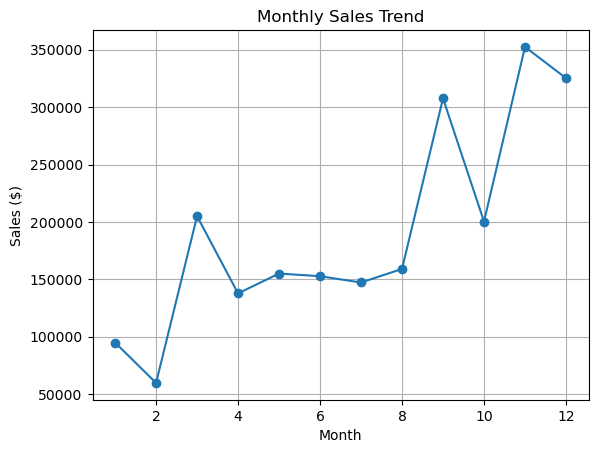

In [32]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.grid()
plt.show()

* Sales dip in February, but increase drastically in March.
* Sales go down again during April, and it remains constant (some flunctuation) until September,where it rapidly increases, then dips again in October.
* Sales increase drastically from February to March, August to September, and October to November.

### Analyzing Profit by Category and Discount:

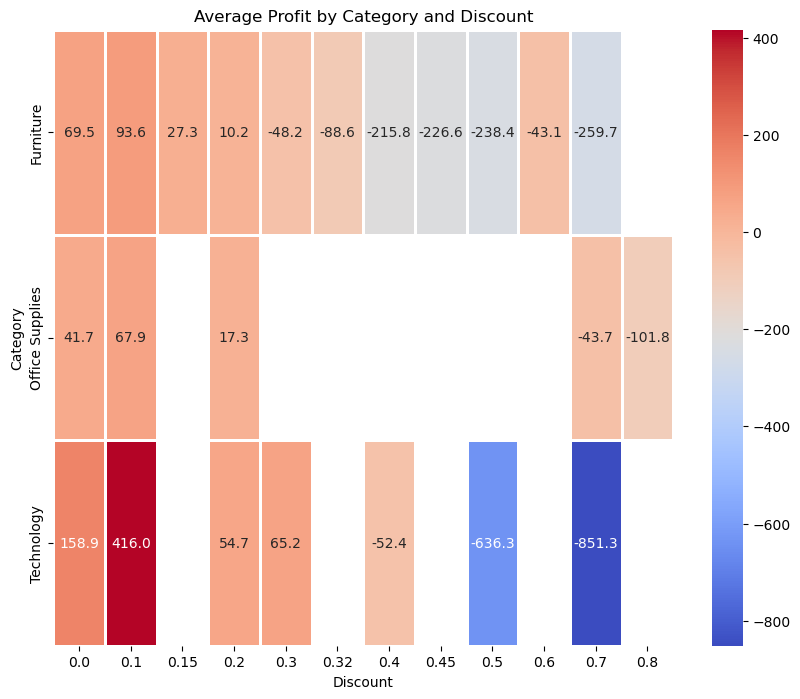

In [36]:
pivot_table = df.pivot_table(
    index='Category',
    columns='Discount',
    values='Profit',
    aggfunc='mean'  # You can also use 'sum' or 'median'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='coolwarm', linewidths=1)
plt.title('Average Profit by Category and Discount')
plt.ylabel('Category')
plt.xlabel('Discount')
plt.show()

* Profit is at its peak when there are no discounts applied.
* Profit still okay at 10% discounts and 20% discounts.
* Profit begins to dip on discounts 30% onwards.
* Profits tend to be much lesser from discounts 50% and so forth.
* Lowest profit recorded at 70% off.

### Analyzing Profit and Sales by State:

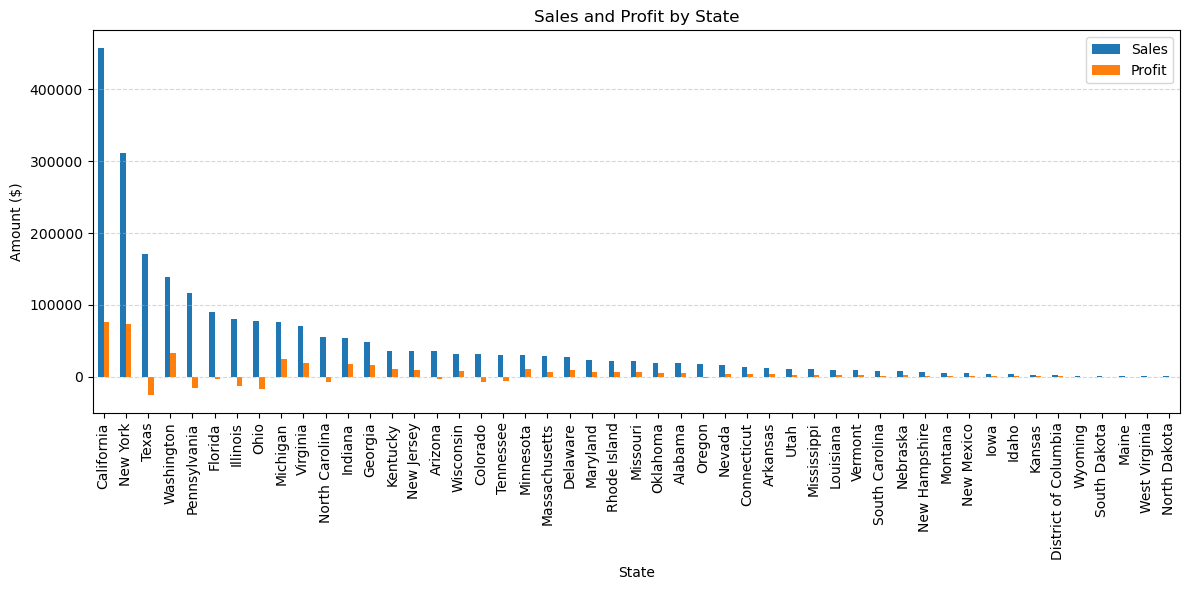

In [40]:
# Group by state and get total Sales and Profit
state_summary = df.groupby('State')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

# bar plot
state_summary.plot(kind='bar', figsize=(12,6))
plt.title('Sales and Profit by State')
plt.xlabel('State')
plt.ylabel('Amount ($)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### We can observe that some states have high sales but low profit. But the question is: why?

### Analyzing Profit and Sales by Sub-Category:

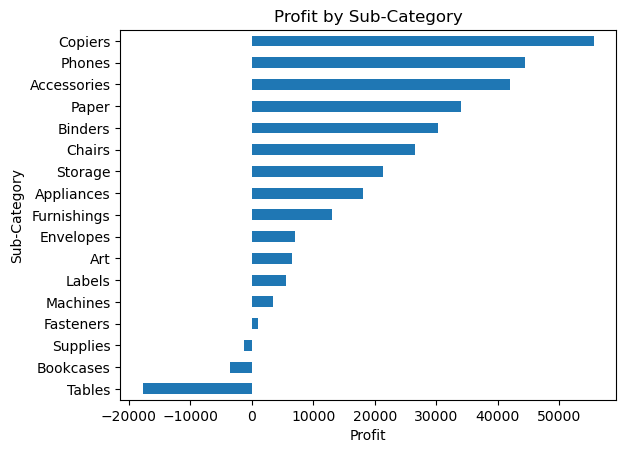

In [44]:
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh')
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()

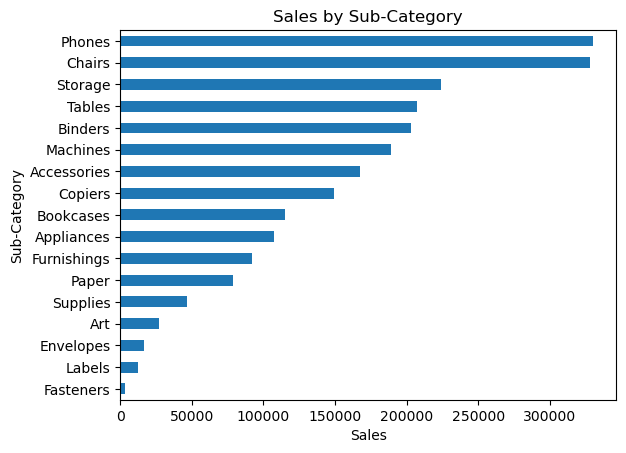

In [46]:
df.groupby('Sub-Category')['Sales'].sum().sort_values().plot(kind='barh')
plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.show()

* Tables have negative profit but gets a good margin of sales.
* The same applies to bookcases and supplies, but not as drastic as Tables.
#### We need to analyze why that happens.

## **4. Problem Statement:**

### Based on our analysis, some states exhibit high sales but relatively low profitability. This discrepancy raises concerns about whether current discount strategies might be adversely affecting profit margins.


### **4.1. Descriptive: What are the average sales, profits, and discounts states with low profit for all categories?**

Before deep diving into the descriptive analysis, more data needs to be processed to make the study more smoother. All columns will be dropped and be left with Segment, State, Category, Sales, Quantity, Discount and Profit. And extra columns will be created

In [53]:
df.drop(['Year', 'Order Date', 'Customer Name', 'Sub-Category','Country', 'City', 'Month', 'Total days for shipping', 'Ship Date', 'Ship Mode'], axis=1, inplace=True)
df.head()

,Segment,State,Region,Category,Product Name,Sales,Quantity,Discount,Profit
0,Consumer,Kentucky,South,Furniture,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,Consumer,Kentucky,South,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,Corporate,California,West,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,Consumer,Florida,South,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,Consumer,Florida,South,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##### **If we compare the profit margin on the same product with Discount and without Discount, grouping it by State is too small so we will group by Region.**

#### Breakdown of Sales, Profit, and Profit margin loss across Regions before and after Discounts:

In [57]:
# Filter only rows with quantity > 0
df_valid = df[df['Quantity'] > 0].copy()

# Compute unit price and full price
df_valid['Unit Price Before Discount'] = df_valid['Sales'] / (df_valid['Quantity'] * (1 - df_valid['Discount']))
df_valid['Full Price Sales'] = df_valid['Unit Price Before Discount'] * df_valid['Quantity']
df_valid['Discounted'] = df_valid['Discount'] > 0

# Separate discounted and non-discounted sets
discounted = df_valid[df_valid['Discounted']]
no_discount = df_valid[~df_valid['Discounted']]

# Group separately by Category and Product (initial step, required for full merge)
disc_group = discounted.groupby(['Region', 'Product Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Full Price Sales': 'sum'
}).rename(columns=lambda x: f'Disc - {x}')

nodisc_group = no_discount.groupby(['Region', 'Product Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Full Price Sales': 'sum'
}).rename(columns=lambda x: f'No Disc - {x}')

# Merge on Category + Product Name
merged = pd.merge(disc_group, nodisc_group, left_index=True, right_index=True, how='inner')

# Compute margins
merged['Disc - Profit % of Full Price'] = (merged['Disc - Profit'] / merged['Disc - Full Price Sales']) * 100
merged['No Disc - Profit % of Full Price'] = (merged['No Disc - Profit'] / merged['No Disc - Full Price Sales']) * 100
merged['Disc - Actual Profit Margin'] = (merged['Disc - Profit'] / merged['Disc - Sales']) * 100
merged['No Disc - Actual Profit Margin'] = (merged['No Disc - Profit'] / merged['No Disc - Sales']) * 100
merged['Discount Margin Impact'] = merged['Disc - Profit % of Full Price'] - merged['Disc - Actual Profit Margin']

# Now group the result by Category (first index level)
category_summary = merged.groupby(level=0).agg({
    'Disc - Sales': 'sum',
    'Disc - Profit': 'sum',
    'Disc - Full Price Sales': 'sum',
    'No Disc - Sales': 'sum',
    'No Disc - Profit': 'sum',
    'No Disc - Full Price Sales': 'sum'
})

# Recalculate margins at the category level
category_summary['Disc - Profit % of Full Price'] = (
    category_summary['Disc - Profit'] / category_summary['Disc - Full Price Sales']
) * 100
category_summary['No Disc - Profit % of Full Price'] = (
    category_summary['No Disc - Profit'] / category_summary['No Disc - Full Price Sales']
) * 100
category_summary['Profit Margin Difference'] = (
    category_summary['No Disc - Profit % of Full Price'] - category_summary['Disc - Profit % of Full Price']
)
# Show the result
category_summary = category_summary.round(2)
category_summary

,Disc - Sales,Disc - Profit,Disc - Full Price Sales,No Disc - Sales,No Disc - Profit,No Disc - Full Price Sales,Disc - Profit % of Full Price,No Disc - Profit % of Full Price,Profit Margin Difference
Region,,,,,,,,,
Central,96580.80,-21518.79,176408.02,126176.13,40803.82,126176.13,-12.20,32.34,44.54
East,145633.46,8486.73,202625.57,165919.59,51476.14,165919.59,4.19,31.02,26.84
South,50487.21,-3055.21,76643.41,77463.57,22832.69,77463.57,-3.99,29.48,33.46
West,55371.66,-534.24,72293.87,85133.25,19601.14,85133.25,-0.74,23.02,23.76


**Insights:**

1. **Central**  
   - Started at 32.34%, dropped to -12.20%.  
   - Total drop: 44.54 percentage points.

2. **East**  
   - Started at 31.02%, dropped to 4.19%.
   - Total drop: 26.84 points.

3. **South**  
   - Started at 29.48%, dropped to -3.99%.
   - Total drop: 33.46 points.

4. **West**  
   - Started at 23.02%, dropped to -0.74%. 
   - Total drop: 23.76 points.
     
Discounting reduced profit margins in all regions the notable ones being Central and South. This indicates a need to re-evaluate discount strategies.


#### Listing the top 10 states with high Sales and top 10 lowest Profits to see note which States are on the same lists: 

In [61]:
# Group total sales by state (highest 10)
states_high_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
high_sales_states = states_high_sales.index

# Filter dataset to just those states
filtered_df = df[df['State'].isin(high_sales_states)]

# Group by State and Region to get totals
sales_by_state = (
    filtered_df.groupby(['State', 'Region'])[['Sales', 'Profit']]
    .sum()
    .sort_values(by='Sales', ascending=False)
    .reset_index()
)

# Rename for clarity
sales_by_state.columns = ['State', 'Region', 'Total Sales', 'Total Profit']

# Display final result
display(sales_by_state)

,State,Region,Total Sales,Total Profit
0,California,West,457687.6315,76381.3871
1,New York,East,310876.2710,74038.5486
2,Texas,Central,170188.0458,-25729.3563
3,Washington,West,138641.2700,33402.6517
4,Pennsylvania,East,116511.9140,-15559.9603
5,Florida,South,89473.7080,-3399.3017
6,Illinois,Central,80166.1010,-12607.8870
7,Ohio,East,78258.1360,-16971.3766
8,Michigan,Central,76269.6140,24463.1876
9,Virginia,South,70636.7200,18597.9504


In [63]:
# Get states with lowest total profit
states_low_profit = df.groupby('State')['Profit'].sum().sort_values().head(10)
low_profit_states = states_low_profit.index

# Filter original DataFrame for those states
filtered_df = df[df['State'].isin(low_profit_states)]

# Group by State and Region to get total sales and profit
profit_by_state = (
    filtered_df.groupby(['State', 'Region'])[['Sales', 'Profit']]
    .sum()
    .sort_values(by='Profit', ascending=True)
    .reset_index()
)

# Rename for clarity
profit_by_state.columns = ['State', 'Region', 'Total Sales', 'Total Profit']

# Display result
display(profit_by_state)


,State,Region,Total Sales,Total Profit
0,Texas,Central,170188.0458,-25729.3563
1,Ohio,East,78258.1360,-16971.3766
2,Pennsylvania,East,116511.9140,-15559.9603
3,Illinois,Central,80166.1010,-12607.8870
4,North Carolina,South,55603.1640,-7490.9122
5,Colorado,West,32108.1180,-6527.8579
6,Tennessee,South,30661.8730,-5341.6936
7,Arizona,West,35282.0010,-3427.9246
8,Florida,South,89473.7080,-3399.3017
9,Oregon,West,17431.1500,-1190.4705


Looking at the top 10 states with high sales , and the top 10 states with low profits , we find 5 states incommon that are Texas, Pennsylvania, Illinois, Ohio and Florida.
thats why we pursued studying the low profit list.

In [66]:
# Group by State only and compute mean/sum
state_summary = (
    filtered_df
    .groupby('State')[['Sales', 'Profit', 'Discount']]
    .agg(['mean', 'sum'])
)

# Flatten MultiIndex columns
state_summary.columns = ['_'.join(col).strip() for col in state_summary.columns.values]
state_summary = state_summary.reset_index()

# Merge in Region info (one Region per State assumed)
region_map = df[['State', 'Region']].drop_duplicates()
state_summary = state_summary.merge(region_map, on='State', how='left')

state_summary = state_summary.sort_values(by='Profit_sum', ascending=True)

# Display top 10
display(state_summary.head(10))

,State,Sales_mean,Sales_sum,Profit_mean,Profit_sum,Discount_mean,Discount_sum,Region
9,Texas,172.779742,170188.0458,-26.121174,-25729.3563,0.370193,364.64,Central
5,Ohio,166.861697,78258.1360,-36.186304,-16971.3766,0.324947,152.40,East
7,Pennsylvania,198.487077,116511.9140,-26.507598,-15559.9603,0.328620,192.90,East
3,Illinois,162.939230,80166.1010,-25.625787,-12607.8870,0.390041,191.90,Central
4,North Carolina,223.305880,55603.1640,-30.083985,-7490.9122,0.283534,70.60,South
1,Colorado,176.418231,32108.1180,-35.867351,-6527.8579,0.316484,57.60,West
8,Tennessee,167.551219,30661.8730,-29.189583,-5341.6936,0.291257,53.30,South
0,Arizona,157.508933,35282.0010,-15.303235,-3427.9246,0.303571,68.00,West
2,Florida,233.612815,89473.7080,-8.875461,-3399.3017,0.299347,114.65,South
6,Oregon,140.573790,17431.1500,-9.600569,-1190.4705,0.288710,35.80,West


* Looking at the 'Profit_sum' the values are high in negative translating high loss.
* The top 3 highest sales in this column 'Illinois' thats ranking on the 7th place , 'Texas' thats ranking on the 3rd place, and 'Pennsylvania' thats ranking on 5th place on the over all highest Sales display high discounts, which means the discounts isnt leading to more profit.
* Despite the fact 'Florida' having the highest Sale mean the profit is drastically low, that supports the matter of discount strategy has flaw.

#### Comparison of Profit, Quantity and Sales before and after Discounts by Region:


In [70]:
# Split into discounted and non-discounted groups
no_discount = df[df['Discount'] == 0].copy()
with_discount = df[df['Discount'] > 0].copy()

# Find Region + Product pairs common to both
no_disc_keys = no_discount[['Region', 'Product Name']].drop_duplicates()
with_disc_keys = with_discount[['Region', 'Product Name']].drop_duplicates()

# Keep only common Region + Product pairs
common_pairs = pd.merge(no_disc_keys, with_disc_keys, on=['Region', 'Product Name'], how='inner')

# Filter the full dataset to those pairs
filtered_df = pd.merge(df, common_pairs, on=['Region', 'Product Name'], how='inner')

# Split filtered data again
no_discount_filtered = filtered_df[filtered_df['Discount'] == 0].copy()
with_discount_filtered = filtered_df[filtered_df['Discount'] > 0].copy()

# Reverse-calculate full price sales for discounted transactions
with_discount_filtered = with_discount_filtered.copy()
with_discount_filtered['Sales'] = with_discount_filtered['Sales'] / (1 - with_discount_filtered['Discount'])


# Group by Region + Product Name and average key metrics
metrics = ['Sales', 'Profit', 'Quantity']
avg_no_discount = no_discount_filtered.groupby(['Region', 'Product Name'])[metrics].mean().add_prefix('No Discount Avg ')
avg_with_discount = with_discount_filtered.groupby(['Region', 'Product Name'])[metrics].mean().add_prefix('With Discount Avg ')

# Merge both summaries
comparison = pd.merge(avg_no_discount, avg_with_discount, left_index=True, right_index=True, how='inner')

# Calculate differences
for metric in metrics:
    comparison[f'Change in {metric}'] = comparison[f'With Discount Avg {metric}'] - comparison[f'No Discount Avg {metric}']

# Reset index to access Region for grouping
comparison = comparison.reset_index()

# Group by Region and SUM all differences and averages
region_summary = comparison.groupby('Region').agg({
    'No Discount Avg Sales': 'sum',
    'With Discount Avg Sales': 'sum',
    'Change in Sales': 'sum',
    'No Discount Avg Profit': 'sum',
    'With Discount Avg Profit': 'sum',
    'Change in Profit': 'sum',
    'No Discount Avg Quantity': 'sum',
    'With Discount Avg Quantity': 'sum',
    'Change in Quantity': 'sum'
})
# Display result
region_summary = region_summary.round(2)
region_summary


,No Discount Avg Sales,With Discount Avg Sales,Change in Sales,No Discount Avg Profit,With Discount Avg Profit,Change in Profit,No Discount Avg Quantity,With Discount Avg Quantity,Change in Quantity
Region,,,,,,,,,
Central,110565.57,118127.61,7562.04,36459.20,-14114.11,-50573.32,1364.62,1458.04,93.42
East,121437.79,124784.23,3346.44,38436.86,5351.39,-33085.47,1590.93,1660.25,69.32
South,60087.82,61103.60,1015.79,17343.63,-1628.24,-18971.86,891.27,902.93,11.67
West,58718.76,49874.59,-8844.17,13145.69,706.17,-12439.52,1020.21,958.83,-61.38


#### Doing a side to side BarPlot for Profit margin before and after discount for Quantity, Sales and Profit to visualize the difference: 

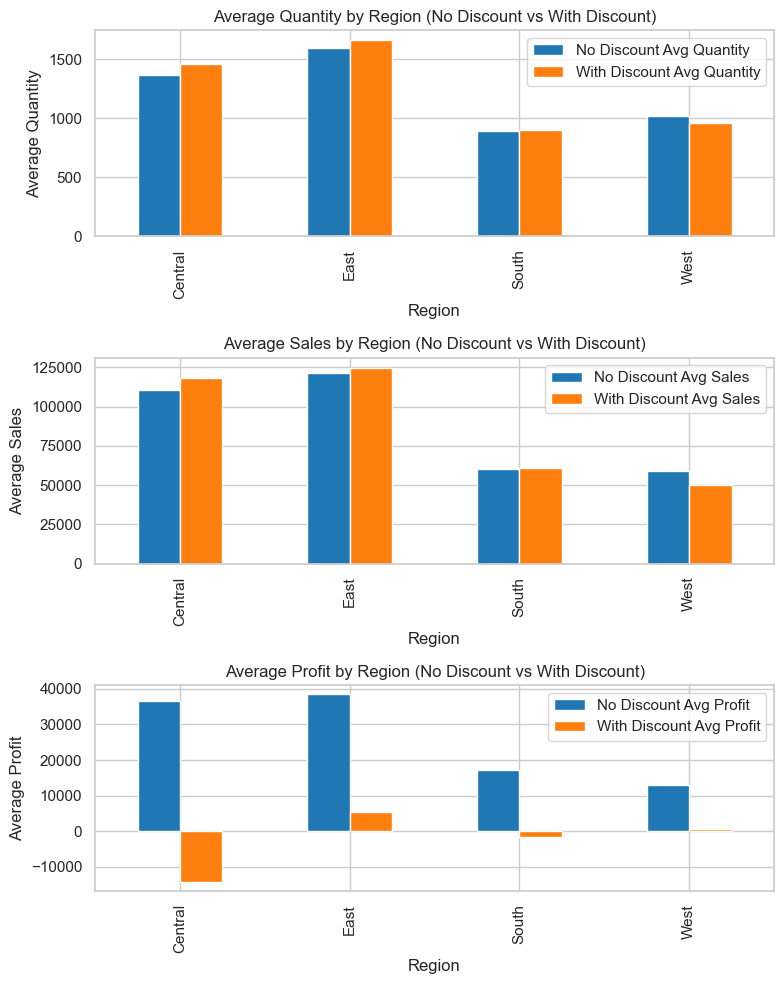

In [73]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Chart 1: Quantity
region_summary[['No Discount Avg Quantity', 'With Discount Avg Quantity']].plot(
    kind='bar', ax=axes[0], title='Average Quantity by Region (No Discount vs With Discount)', color=['#1f77b4', '#ff7f0e']
)
axes[0].set_ylabel('Average Quantity')
axes[0].legend(loc='upper right')

# Chart 2: Sales
region_summary[['No Discount Avg Sales', 'With Discount Avg Sales']].plot(
    kind='bar', ax=axes[1], title='Average Sales by Region (No Discount vs With Discount)', color=['#1f77b4', '#ff7f0e']
)
axes[1].set_ylabel('Average Sales')
axes[1].legend(loc='upper right')

# Chart 3: Profit
region_summary[['No Discount Avg Profit', 'With Discount Avg Profit']].plot(
    kind='bar', ax=axes[2], title='Average Profit by Region (No Discount vs With Discount)', color=['#1f77b4', '#ff7f0e']
)
axes[2].set_ylabel('Average Profit')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

**Descriptive Insights:** 

- Profit margins dropped sharply across all regions due to discounting:
    - **Central**: From 32.34% to -12.20% (drop of 44.54 points)
    - **East**: From 31.02% to 4.19% (drop of 26.84 points)
    - **South**: From 29.48% to -3.99% (drop of 33.46 points)
    - **West**: From 23.02% to -0.74%(drop of 23.76 points)

- Discounting boosted sales quantity in the Central, East, and South regions, but came at the cost of significant profit losses across the board. In the West, both sales and quantity dropped, indicating deeper pricing issues.

- High‑sales states like Illinois(7th), Texas(3rd), and Pennsylvania(5th) suffered significant losses due to deep discounts. Even the top‑selling state, Florida, experienced drastically low profits despite strong sales, underscoring the fundamental flaws in the discounting approach.

These findings highlight the urgent need to re‑evaluate discount strategies. Focusing on lower or targeted discount ranges can help balance sales quantity and overall profitability across all regions and key states.


### **4.2. Explaratory: Is there a visible trend between discount levels and profitability in the categories?**

#### Finding clusters based on Profit margins before and after Discount:

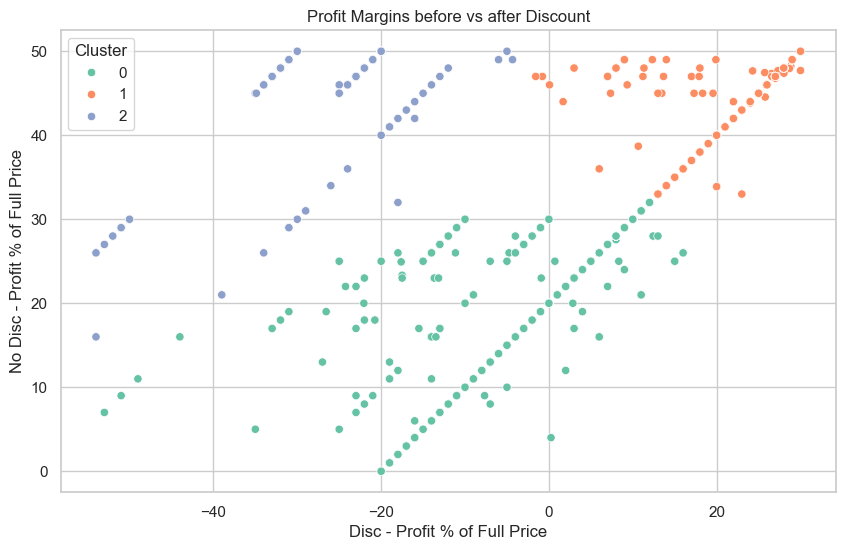

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Select features
features = merged[['Disc - Profit % of Full Price', 'No Disc - Profit % of Full Price']].dropna()

# Standardize data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
features['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=features, x='Disc - Profit % of Full Price', y='No Disc - Profit % of Full Price', hue='Cluster', palette='Set2')
plt.title('Profit Margins before vs after Discount')
plt.grid(True)
plt.show()

There are 3 Clusters, each representing the level of discount and how it affected the profit margin:

1- Green cluster (0): Moderate profit loss after discount. 2- Orange cluster (1): High profit margin before and after discount. 3- Blue cluster (2): Significant drop in profit after discount.

Insights:

* Green cluster shows that discounts had a moderate effect — could be acceptable depending on volume.
* Orange cluster shows that discounts had minimal impact — products remain profitable.
* Blue cluster shows high profit before discount but large losses after — over-discounted.
There is a point beyond which discounting significantly harms profitability and should be avoided.

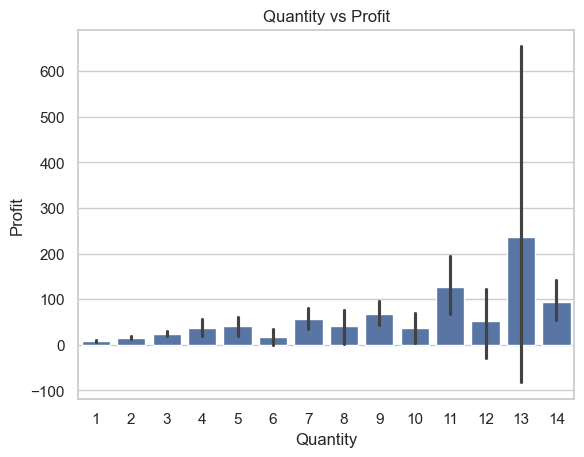

In [80]:
sns.barplot(data=df, x='Quantity', y='Profit') ###barplot looks clearer but we can easily revert to scatterplot
plt.title('Quantity vs Profit')
plt.show()

As Quantity increases Profit also increases.

<Axes: title={'center': 'Total Negative Profit by Category'}, xlabel='Category'>

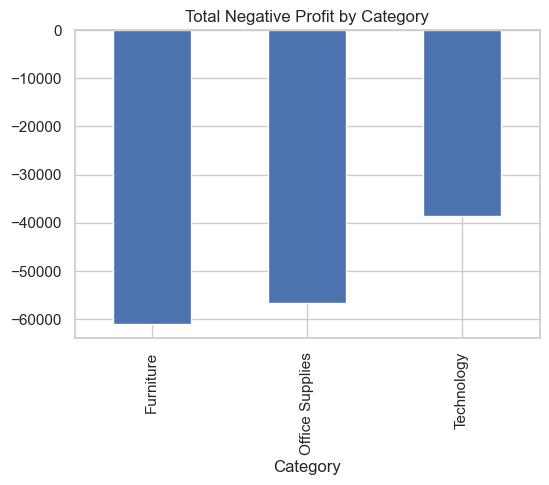

In [83]:
negative_profit = df[df['Profit']<0]
neg_profit_by_cat = negative_profit.groupby('Category')['Profit'].sum().sort_values()
neg_profit_by_cat.plot(kind='bar', title='Total Negative Profit by Category', figsize=(6,4))

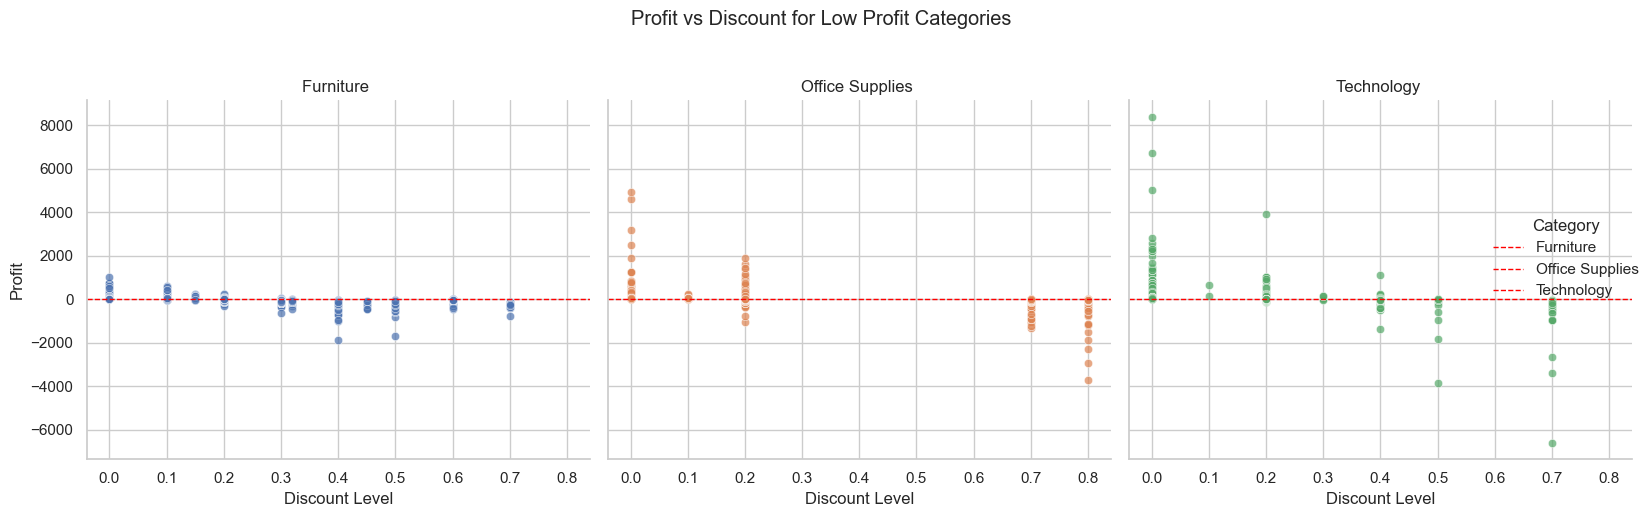

In [84]:
g = sns.FacetGrid(df, col="Category", hue="Category", col_wrap=3, height=5)
g.map(sns.scatterplot, "Discount", "Profit", alpha=0.7)
g.map(plt.axhline, y=0, color='red', linestyle='--', lw=1) # Apply axhline to each facet
g.set_titles("{col_name} ")
g.set_axis_labels("Discount Level", "Profit")
g.add_legend()
plt.suptitle('Profit vs Discount for Low Profit Categories', y=1.03)
plt.tight_layout()
plt.show()

The relationship between discounts and profits is very clear in the technology category, when there is no discounts, profits are very high. As discount levels increase, profits visibly decrease.
* The company needs to stop discounting office Supplies and Furniture past 20 % and 30% for Technology.

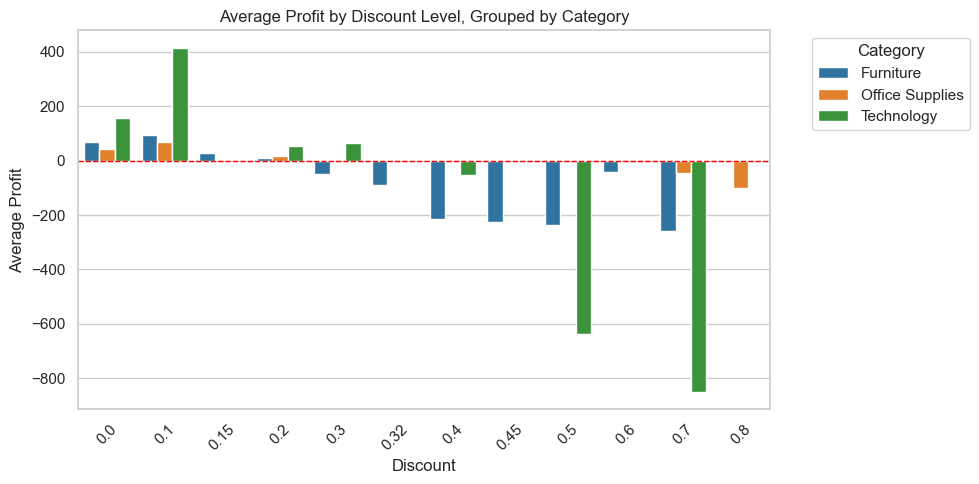

In [88]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df, x='Discount', y='Profit', hue='Category', estimator=np.mean, errorbar=None, palette='tab10')
plt.title('Average Profit by Discount Level, Grouped by Category')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.axhline(0, color='red', linestyle='--', lw=1)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Discounts have no significant impact on the office supplies category but major losses for technology and Furniture.

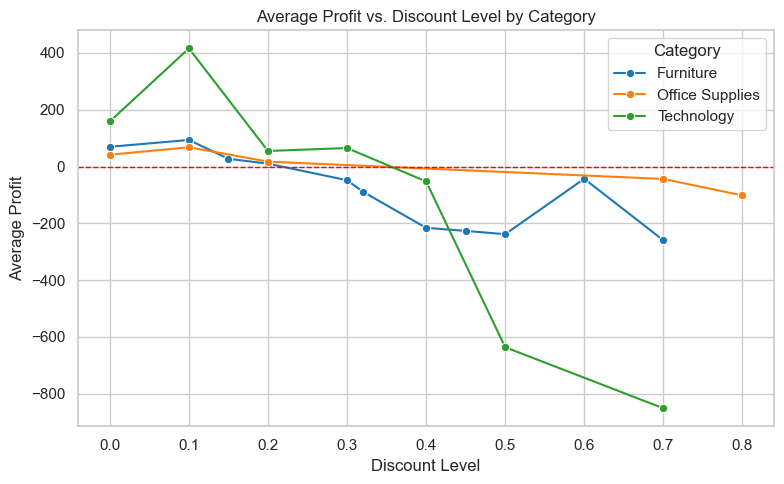

In [92]:
avg_profit_by_discount_category = df.groupby(['Category', 'Discount'])['Profit'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=avg_profit_by_discount_category, x='Discount', y='Profit', hue='Category', marker='o', palette='tab10')
plt.title('Average Profit vs. Discount Level by Category')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.axhline(0, color='red', linestyle='--', lw=1)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

Profit is inversely proportional to discounts

#### Average Profit vs Discount per Category:

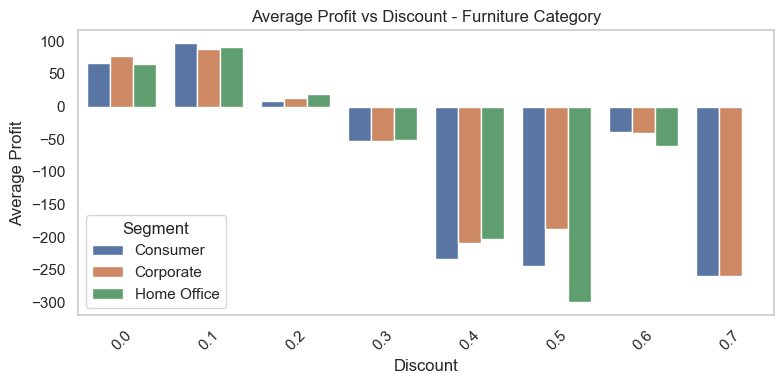

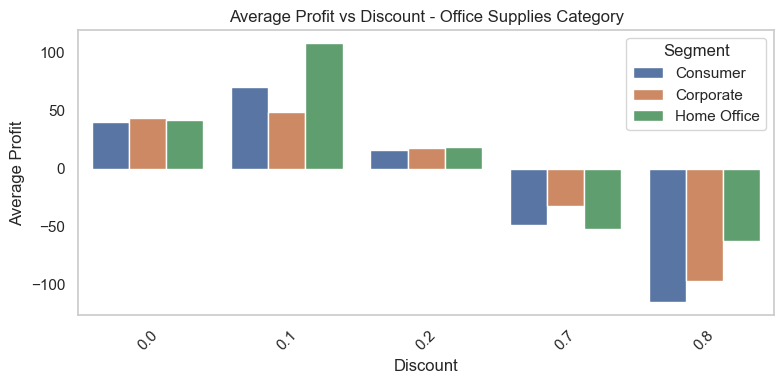

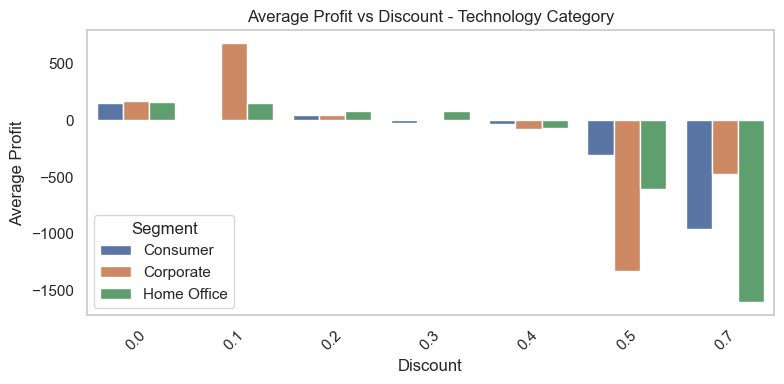

In [96]:
df['DiscountRounded'] = df['Discount'].round(1)

grouped = df.groupby(['Segment', 'Category', 'DiscountRounded'])['Profit'].mean().reset_index()

categories = grouped['Category'].unique()

for category in categories:
    data_subset = grouped[grouped['Category'] == category]

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=data_subset,
        x='DiscountRounded',
        y='Profit',
        hue='Segment'
    )

    plt.title(f"Average Profit vs Discount - {category} Category")
    plt.xlabel("Discount")
    plt.ylabel("Average Profit")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

**Summary of Profit vs Discount Trends:**

- Furniture: Profits are positive at low discounts (0–20%), but drop sharply and turn highly negative from 30–70%.
- Office Supplies: Profits stay steady or positive at low discounts, especially for Home Office (~10%), but turn negative at higher discounts (70–80%).
- Technology: Profits fall drastically as discounts rise (30–70%), with Home Office seeing the biggest losses (>–1,600).
  
**Overall:**
Low discounts (0–20%) maintain profitability across all categories, while higher discounts (30–80%) lead to significant losses — especially for Technology and Home Office segments.

### **4.3. Inferential: Is the average profit in high-discount orders significantly lower than in low-discount ones?**

#### Performing T-test:

In [101]:
from scipy.stats import ttest_ind
from scipy.stats import f

# 2 Groups
low_discount = df[df['Discount'] < 0.3]['Profit']
high_discount = df[df['Discount'] >= 0.3]['Profit']

f_stat = np.var(low_discount, ddof=1) / np.var(high_discount, ddof=1)

df1 = len(low_discount) - 1
df2 = len(high_discount) - 1

alpha = 0.05

f_critical = f.ppf(1 - alpha, df1, df2)
print("F-statistic:", f_stat)
print("F-critical value:", f_critical)

if f_stat > f_critical:
    print("Reject null hypothesis → Variances are significantly different")
else:
    print("Fail to reject → Variances are equal")

F-statistic: 0.4047320059342315
F-critical value: 1.0705455108394835
Fail to reject → Variances are equal


In [103]:
# T-test
t_stat, p_val = ttest_ind(low_discount, high_discount, equal_var=True)
print("T-test results:")
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-test results:
T-statistic: 22.134190085874568
P-value: 5.092886028896182e-106


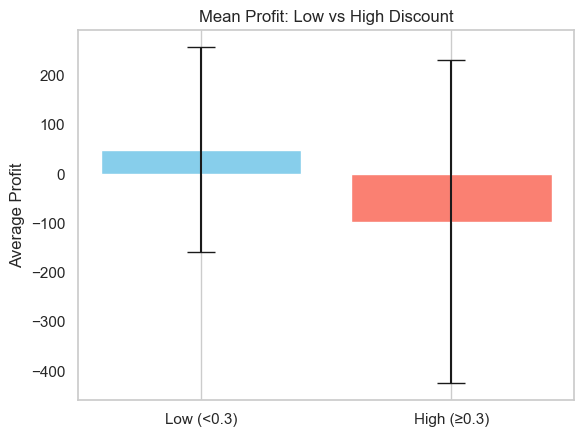

In [105]:
means = [low_discount.mean(), high_discount.mean()]
errors = [low_discount.std(), high_discount.std()]

plt.bar(['Low (<0.3)', 'High (≥0.3)'], means, yerr=errors, capsize=10, color=['skyblue', 'salmon'])
plt.title("Mean Profit: Low vs High Discount")
plt.ylabel("Average Profit")
plt.grid(axis='y')
plt.show()

##### A T-test was conducted to compare profits between two discount groups: Low Discount (< 0.3) and High Discount (≥ 0.3). Prior to the test, we checked for equality of variances and confirmed that the variances are equal.
* The P-value is extremely small, much less than 0.05.

* The test found there is a statistically significant difference in the means of the two groups (low vs. high discount).

#### Before we go into the next test, let's seperate Discount values into bins:

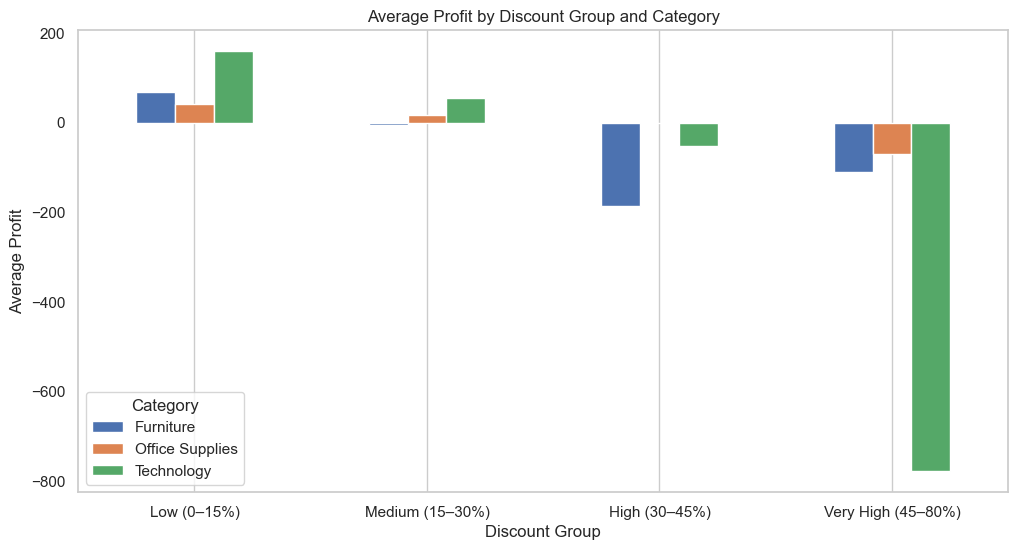

In [109]:
# Create discount bins and labels
bins = [-0.01, 0.15, 0.3, 0.45, 0.8]
labels = ['Low (0–15%)', 'Medium (15–30%)', 'High (30–45%)', 'Very High (45–80%)']

# Categorize the discounts into bins
df['Discount Group'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# Group by Discount Group and Category, then plot average profit
df.groupby(['Discount Group', 'Category'], observed=True)['Profit'].mean().unstack().plot(kind='bar', figsize=(12, 6))

# Plot formatting
plt.title("Average Profit by Discount Group and Category")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

#### Performing Anova test:

In [112]:
from scipy.stats import f_oneway


bins = [-0.01, 0.15, 0.3, 0.45, 0.8]

df['Discount Bin'] = pd.cut(df['Discount'], bins=bins)


grouped = [group['Profit'].dropna() for _, group in df.groupby('Discount Bin',observed = True) if len(group) > 0]

# ANOVA test
from scipy.stats import f_oneway
f_stat, p_val = f_oneway(*grouped)

print("ANOVA results:")
print("F-statistic:", f_stat)
print("P-value:", p_val)


ANOVA results:
F-statistic: 186.44574043313452
P-value: 1.2151144339663672e-117


#### Anova Test
* The P-value is nearly zero.
* Conclusion: Reject the null hypothesis. There is at least one discount bin with a significantly different mean profit compared to the others.
* Insight: The level of discount has a strong effect on profit, but the relationship is not linear — it's better explained by evaluating profit across specific discount intervals rather than just "low vs. high".

#### Performing a deeper analysis after ANOVA called Tukey HSD:

##### Tukey HSD Test at 5% Significance

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
     group1           group2        meandiff p-adj    lower     upper   reject
------------------------------------------------------------------------------
  High (30–45%)        Low (0–15%)  181.5515    0.0  143.1329  219.9702   True
  High (30–45%)    Medium (15–30%)  135.1026    0.0   96.4382   173.767   True
  High (30–45%) Very High (45–80%)    9.2364 0.9431  -32.9395   51.4124  False
    Low (0–15%)    Medium (15–30%)  -46.4489    0.0    -59.01  -33.8878   True
    Low (0–15%) Very High (45–80%) -172.3151    0.0 -193.3307 -151.2994   True
Medium (15–30%) Very High (45–80%) -125.8662    0.0 -147.3278 -104.4045   True
------------------------------------------------------------------------------


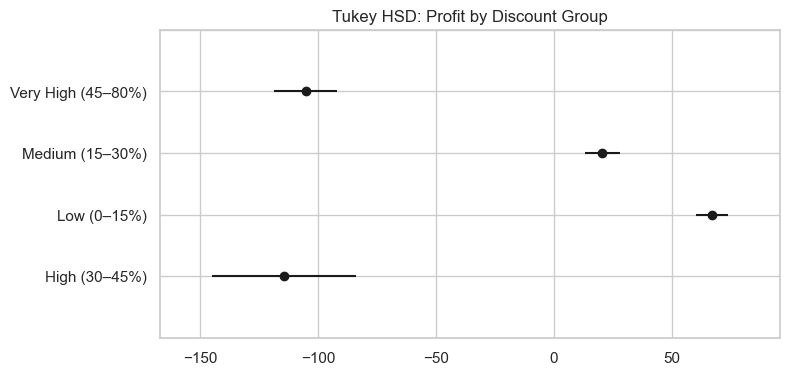

In [117]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['Profit'],
                          groups=df['Discount Group'],
                          alpha=0.05)

print(tukey)

# plot the results
tukey.plot_simultaneous(figsize=(8, 4))
plt.title("Tukey HSD: Profit by Discount Group")
plt.grid(True)
plt.show()


##### Tukey HSD Test at 1% Significance

             Multiple Comparison of Means - Tukey HSD, FWER=0.01              
     group1           group2        meandiff p-adj    lower     upper   reject
------------------------------------------------------------------------------
  High (30–45%)        Low (0–15%)  181.5515    0.0  134.9904  228.1126   True
  High (30–45%)    Medium (15–30%)  135.1026    0.0   88.2436  181.9616   True
  High (30–45%) Very High (45–80%)    9.2364 0.9431  -41.8783   60.3512  False
    Low (0–15%)    Medium (15–30%)  -46.4489    0.0  -61.6722  -31.2256   True
    Low (0–15%) Very High (45–80%) -172.3151    0.0 -197.7848 -146.8454   True
Medium (15–30%) Very High (45–80%) -125.8662    0.0 -151.8764  -99.8559   True
------------------------------------------------------------------------------


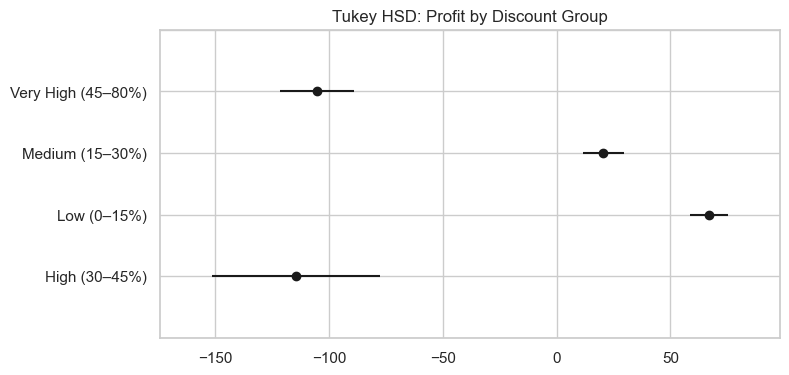

In [119]:
# Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['Profit'],
                          groups=df['Discount Group'],
                          alpha=0.01)

print(tukey)

# plot the results
tukey.plot_simultaneous(figsize=(8, 4))
plt.title("Tukey HSD: Profit by Discount Group")
plt.grid(True)
plt.show()

The Tukey HSD analysis consistently indicates that offering at least a 30% discount leads to significantly better profits. There is no additional benefit beyond 45%, as High and Very High groups yield statistically similar outcomes.

**Final Conclussion for inferential**
* Discount has a statistically significant effect on profit – confirmed both by overall ANOVA and direct t-tests comparing low vs. high discount groups.
* Not all discount levels yield the same results – there's evidence of an optimal range that maximizes profit rather than a simple "higher is better" rule.
* Post-hoc Tukey HSD analysis reveals which specific discount ranges differ – confirming where the true differences lie.
* At both 5% and 1% family-wise significance levels, results are consistent: offering a minimum of 30% discount significantly boosts profits compared to lower discount levels, and increasing beyond 45% offers no additional benefit, as the High (30–45%) and Very High (45–80%) groups show no significant difference.

### **4.4. Predictive: How accurately can the profitability of an order, measured by its Profit Ratio, be predicted through Discount and Quantity?**

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [127]:

feature_cols = ['Sales', 'Quantity', 'Discount', 'Category', 'Segment']
X = df[feature_cols]
y = df['Profit']

print("Selected Features (X):")
print(X.head())
print("\nTarget Variable (y):")
print(y.head())

Selected Features (X):
      Sales  Quantity  Discount         Category    Segment
0  261.9600         2      0.00        Furniture   Consumer
1  731.9400         3      0.00        Furniture   Consumer
2   14.6200         2      0.00  Office Supplies  Corporate
3  957.5775         5      0.45        Furniture   Consumer
4   22.3680         2      0.20  Office Supplies   Consumer

Target Variable (y):
0     41.9136
1    219.5820
2      6.8714
3   -383.0310
4      2.5164
Name: Profit, dtype: float64


* What I see in the output of this code is that there are five rows, and five columns as the input variables (sales, quantity, discount, category, and segment). The y variable (output) shows that the return in profit is not as high as the amount of sales, and I predict that discounts negatively impact this.

In [130]:
print(f"Number of unique Categories: {df['Category'].nunique()}")
print(df['Category'].unique())

print(f"\nNumber of unique Segments: {df['Segment'].nunique()}")
print(df['Segment'].unique())

Number of unique Categories: 3
['Furniture' 'Office Supplies' 'Technology']

Number of unique Segments: 3
['Consumer' 'Corporate' 'Home Office']


In [132]:
X_encoded = pd.get_dummies(X, columns=['Category', 'Segment'], drop_first=True)
X_encoded.head()

,Sales,Quantity,Discount,Category_Office Supplies,Category_Technology,Segment_Corporate,Segment_Home Office
0,261.9600,2,0.00,False,False,False,False
1,731.9400,3,0.00,False,False,False,False
2,14.6200,2,0.00,True,False,True,False
3,957.5775,5,0.45,False,False,False,False
4,22.3680,2,0.20,True,False,False,False


* Category and Segment columns are further divided to specify their types. Because of the "drop_first=True" command, category only displays two of its type and segment displays two of its type, to avoid multicollinetary. For example, if two null values are presented, each for "Category_Office" and "Category_Technology," we can safely assume that the non-null value goes to the third of its type, "Category_Furniture."
* True and false values are treated as 1s and 0s. Converting these columns into numerical values is needed for the regression model.

In [135]:
display(X_encoded.head().style.highlight_max(axis=0, color='lightgreen'))

,Sales,Quantity,Discount,Category_Office Supplies,Category_Technology,Segment_Corporate,Segment_Home Office
0,261.960000,2,0.000000,False,False,False,False
1,731.940000,3,0.000000,False,False,False,False
2,14.620000,2,0.000000,True,False,True,False
3,957.577500,5,0.450000,False,False,False,False
4,22.368000,2,0.200000,True,False,False,False


* Maximum value for each column.

In [138]:
missing_X = X_encoded.isnull().sum().to_frame(name='Missing Values in X_encoded')
display(missing_X)

missing_y = y.isnull().sum()
print(f"\nMissing values in y (target - Profit): {missing_y}")

,Missing Values in X_encoded
Sales,0
Quantity,0
Discount,0
Category_Office Supplies,0
Category_Technology,0
Segment_Corporate,0
Segment_Home Office,0



Missing values in y (target - Profit): 0


In [140]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7995, 7)
Shape of X_test: (1999, 7)
Shape of y_train: (7995,)
Shape of y_test: (1999,)


* Model trained, split 80/20

In [143]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

* Linear model trained.

In [146]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

y_pred = linear_model.predict(X_test)

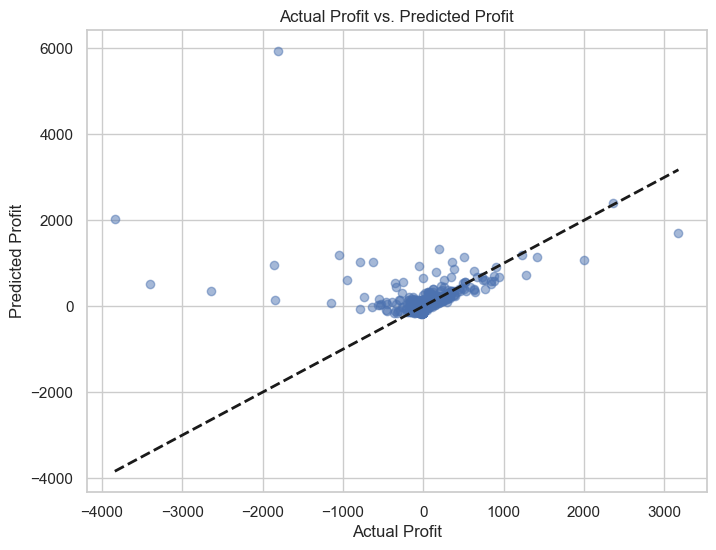

In [148]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual Profit vs. Predicted Profit")
plt.grid(True)
plt.show()

* R-squared value : What percent of "Profit changes" our model can explain.
* Mean Absolute Error: Average dollar amount our predictions are off by.
* Root Mean Squared Error: Another average dollar amount our predictions are off by (sensitive to big errors).

In [151]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²) Score: {r2:.2f}")

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

from sklearn.metrics import mean_squared_error
import numpy as np # For square root (np.sqrt)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-squared (R²) Score: -0.75
Mean Absolute Error (MAE): $69.58
Root Mean Squared Error (RMSE): $291.16


* R-squared value should range from 0-1. It is the percentage of how the profit varies with the input variables. Our score is negative, not a good score.
* If linear model doesn't work, this means the profit relationship with our current inputs is more complex and non-linear.

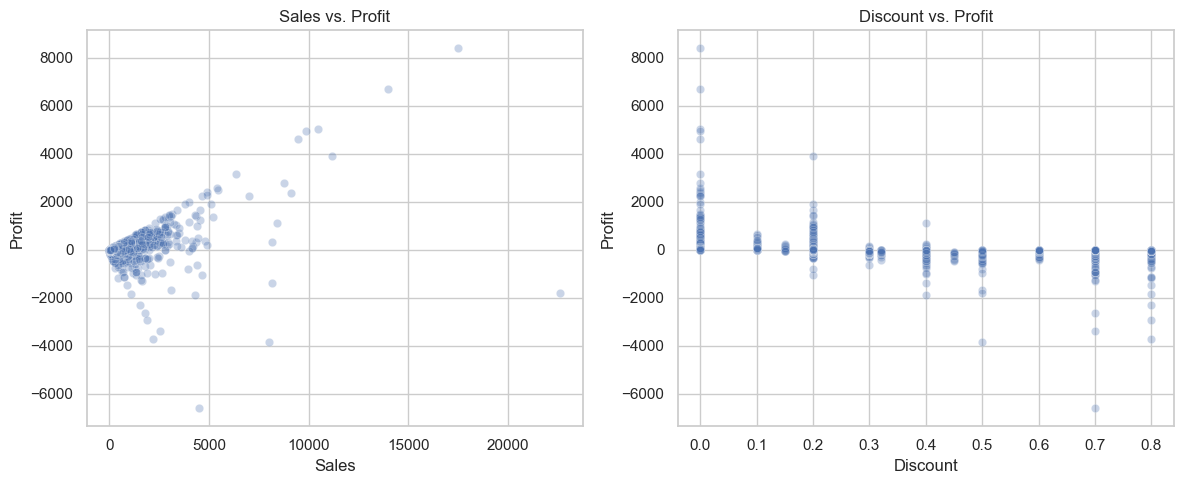

In [154]:
# Create scatter plots to see relationships
plt.figure(figsize=(12, 5))

# Sales vs. Profit
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st subplot
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.3)
plt.title('Sales vs. Profit')

# Discount vs. Profit
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd subplot
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3)
plt.title('Discount vs. Profit')

plt.tight_layout()
plt.show()

* Though a linear pattern is visible in the comparison between sales and profit, the overall chart does not display complete linerarity. This is the same for the comparison between discount and profit.

In [157]:
feature_cols = ['Quantity', 'Discount']
X = df[feature_cols]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²) Score: {r2:.2f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-squared (R²) Score: 1.00
Mean Absolute Error (MAE): $0.00
Root Mean Squared Error (RMSE): $0.00


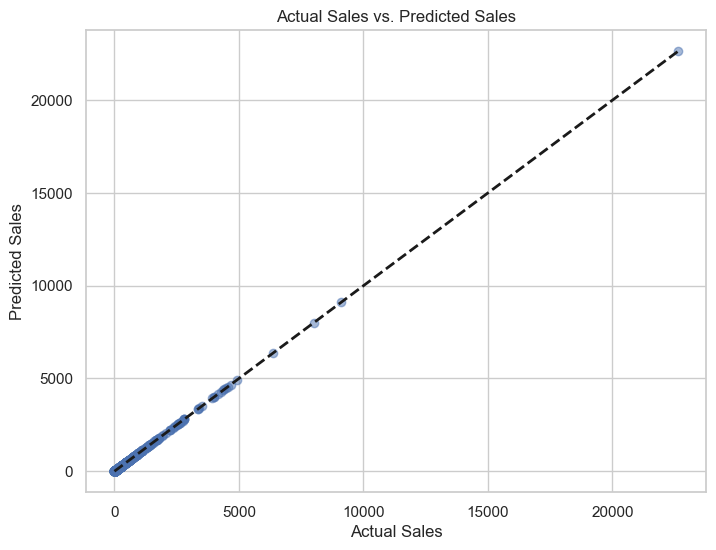

In [159]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs. Predicted Sales")
plt.grid(True)
plt.show()

* An observation to be made here is that sales is 100% predictable with the chosen values "Quantity" and "Discount." A possible reason why the linear regression didn't work with predicting profit is because profit can't be measured in a linear fashion, since it also depends on how much sales are made. Therefore, we can hypothesize that profit could be more viable for prediction if it was measured as a ratio alongside how many sales are made.

In [162]:
# Using a profit ratio as the y variable (Profit/Sales).
# To avoid division by zero, we'll filter out any rows where Sales is 0 or less.
df = df[df['Sales'] > 0]
df['Profit_Ratio'] = df['Profit'] / df['Sales']

feature_cols = ['Discount', 'Category', 'Segment']
X_initial = df[feature_cols]
y = df['Profit_Ratio']

In [164]:
# One-hot encode the categorical features
X_encoded = pd.get_dummies(X_initial, columns=['Category', 'Segment'], drop_first=True)
    
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [166]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [168]:
y_pred = model.predict(X_test)
    
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R²) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared (R²) Score: 0.7491
Mean Absolute Error (MAE): 0.1653
Root Mean Squared Error (RMSE): 0.2371


* While the score here is not as pristine as the predicted sales, it is a better outcome than the previous linear regression where we tried to predict profit without taking to account how much it relied on sales.

In [171]:
coefficients = pd.DataFrame(model.coef_, X_encoded.columns, columns=['Coefficient'])
sorted_coefficients = coefficients.sort_values('Coefficient', ascending=False)

print("\nModel Coefficients (Drivers of Profit Ratio)")
display(sorted_coefficients.style.background_gradient(cmap='viridis'))


Model Coefficients (Drivers of Profit Ratio)


,Coefficient
Category_Office Supplies,0.073723
Category_Technology,0.038802
Segment_Home Office,0.010743
Segment_Corporate,0.005769
Discount,-1.941843


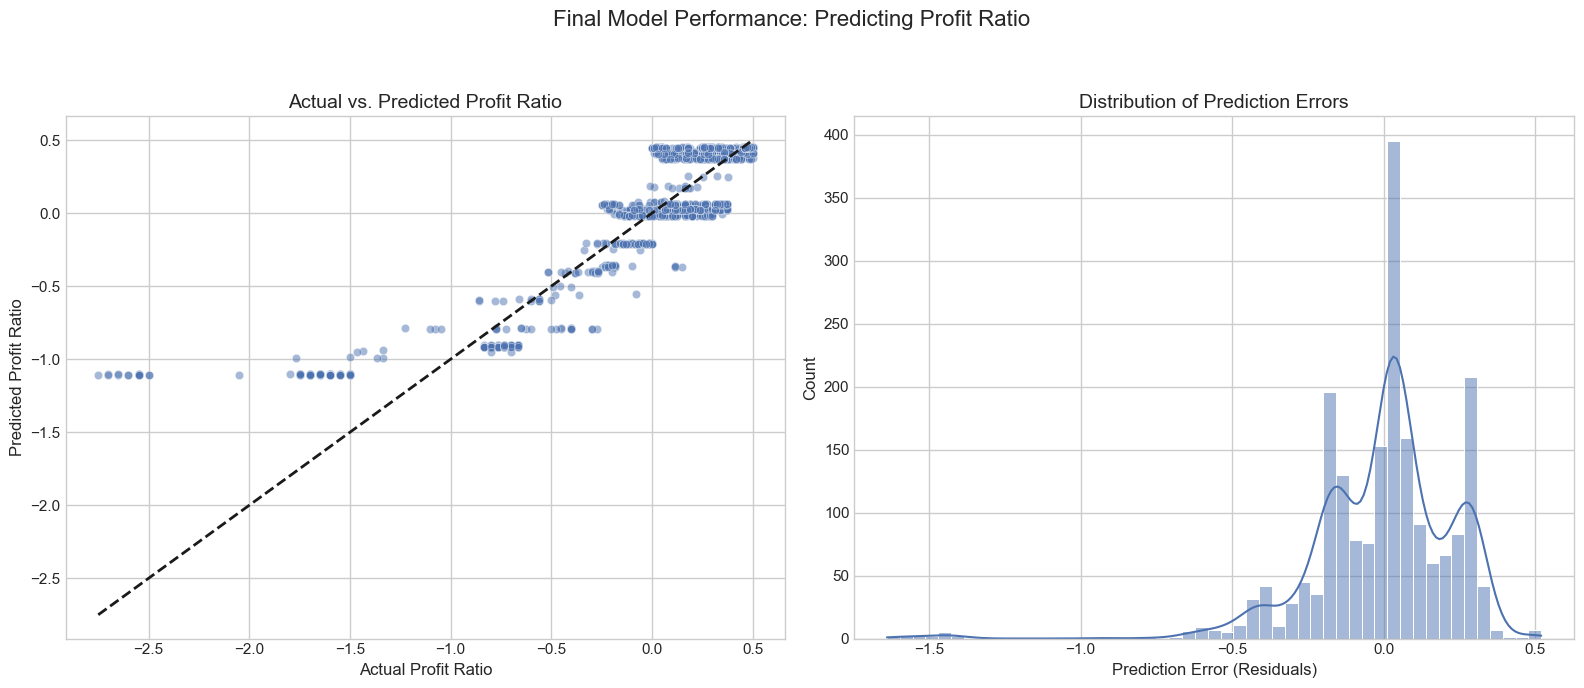

In [173]:
residuals = y_test - y_pred
    
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Final Model Performance: Predicting Profit Ratio', fontsize=16)

# Plot 1: Actual vs. Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)
axes[0].set_xlabel("Actual Profit Ratio", fontsize=12)
axes[0].set_ylabel("Predicted Profit Ratio", fontsize=12)
axes[0].set_title("Actual vs. Predicted Profit Ratio", fontsize=14)

# Plot 2: Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel("Prediction Error (Residuals)", fontsize=12)
axes[1].set_title("Distribution of Prediction Errors", fontsize=14)
    
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

The initial question regarding whether profit can be predicted was a simple one at first. All we had to do was input 'Profit' as the y variable for a linear regression model and take numerical/categorical values from the dataset to fill in as x variables. After doing the testing, a negative score was given and that implied that profit couldn't be easily predicted simply by applying a regression model to our analysis. An idea came up that made us ask whether sales was predictable through the linear regression model, with only using the numerical values this time, "Quantity" and "Discount", as x variables. Logicially, the amount of profit made is solely dependent on how much sales are made, because without sales, there's no profit. After testing the predictability of sales through the linear regression model, it returned a perfect score of 100%, which allowed us to continue further with our analysis by creating a profit ratio (Profit / Sales). After creating this new ratio, then putting it to the test through a linear regression model once again, we came up with a sufficient result of almost 75%, which answered our initial question in the first place. Yes, profit could be predicted with the numerical and categorical values given in the dataset, but taking into account that profit can't be isolated for linear measurement.

## **5. Conclusion:**

**Exploratory Data Analysis (EDA)**  
- Analyzed **Ship Mode vs Profit**: No significant trend observed between shipment modes and profit.  
- Compared metrics for sales, quantity, and profits across **with discount** and **without discount** scenarios.  
- Evaluated average sales, profits, and quantity sold across discount levels for all **Regions**, **Segments**, and **Categories**.

**Regional Focus and Comparison**  
- Focused on **Regions** due to larger sample sizes, making statistical comparisons more robust.  
- Enables direct comparisons between identical products sold **with vs. without discount**, yielding more credible results.

**Impact of Discounts on Sales Per Region**  


| Region  | Sales Change | Profit Change | Quantity Change |
|---------|--------------|----------------|-----------------|
| Central | +7,562.04    | -50,573.32     | +93.42           |
| East    | +3,346.44    | -33,085.47     | +69.32           |
| South   | +1,015.79    | -18,971.86     | +11.67           |
| West    | -8,844.17    | -12,439.52     | -61.38           |

Although discounts drive higher sales and quantity sold, the sharp drop in profits across all regions clearly highlights the need to re‑evaluate discount strategies. Focusing on lower or more targeted discount ranges will help balance sales quantity and overall profitability.

**Discount Clusters and Profitability**  
- **Green Cluster**: Moderate profit loss after discount — acceptable if sales volume justifies it.  
- **Orange Cluster**: High profit margin sustained before and after discount — ideal range.  
- **Blue Cluster**: Significant drop in profit after discount — over‑discounted, should be avoided.
  
**Category Insights**  
- **Furniture**: Profits remain stable at low discounts (0–20%), sharply drop after ~30–70%.  
- **Office Supplies**: Maintain marginal profits until higher discounts of ~60–70%; losses dominate beyond that range.  
- **Technology**: Most susceptible segment, with sharp losses occurring at discounts >30% Home Office seeing the biggest losses.

**Predictive Modeling Summary**  
Initially, a direct linear regression of Profit yielded a **negative score**, indicating that Profit couldn’t be reliably predicted with available features.  
To investigate further, Sales was tested as a target using only **Quantity** and **Discount** as inputs — yielding a **100% prediction accuracy**.  
Since Profit is intrinsically tied to Sales, a **Profit Ratio** (Profit / Sales) was introduced, allowing a new linear regression approach. This achieved roughly **75% accuracy**, confirming that Profit can be reliably estimated when expressed relative to Sales, making it predictable within the available dataset constraints.

**Statistical Inference Insights**  
- The t‑test comparing **low** vs. **high discount** groups confirms a significant difference in profits, supporting the idea that higher discounts affect profitability.  
- ANOVA results further reveal that not all discount levels have the same impact, indicating an **optimal range** rather than a simple "more is better" trend.  
- The **Post‑hoc Tukey HSD** test identifies precisely which discount ranges differ significantly from others.  
- At both **5%** and **1%** significance levels, results are consistent: offering a discount of roughly **30%** significantly improves profits compared to lower discounts, while increasing beyond **45%** provides no additional benefit.  


**Final Insights**  
- Maintain discounts within the **0–30% range** for balanced quantity sold and profit margins across most segments and regions.  
- Adopt **targeted discount policies** for sensitive categories (e.g., low discounts for Technology and Home Office).  
- Leverage **regional analyses** to fine‑tune pricing strategies, ensuring discounts align with consumer behavior and maximize overall profitability.
